# 05 - Phase 2: Round of 32

Freezes the tournament at the start of the round of 32 and predicts it. The model is trained only on matches played **before this round began**, and the simulation is *conditioned* on everything already settled: the group stage and every earlier knockout round are locked in, and we roll dice only from this round onward. Because this round has since been played, we also **score our predictions against the actual results** at the end.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wcpredictor.config import default_config
from wcpredictor.data import (load_matches, load_groups,
                              load_tournament_state,
                              build_training_matches, phase_start_dates,
                              actual_knockout_ties)
from wcpredictor.models import PoissonModel
from wcpredictor.simulation import TournamentSimulator
from wcpredictor.simulation.tournament import STAGES, _STAGE_INDEX
from wcpredictor import visualization as viz

config = default_config()
plt.rcParams['figure.figsize'] = (9, 4.5)
STAGE = 'round_of_32'
NEXT = STAGES[_STAGE_INDEX[STAGE] + 1]  # the round winners advance to
A_COLOR, B_COLOR = '#2980b9', '#c0392b'
label = STAGE.replace('_', ' ')

## Point-in-time training

Train on every match played strictly before this round started, so the model never sees a result it is about to predict.

In [2]:
matches = load_matches(config)
cutoff = pd.Timestamp(phase_start_dates(config)[STAGE])
train = matches[matches['date'] < cutoff]
print(f'The {label} starts {cutoff.date()}.')
print(f'Training on {len(train)} matches played before it; '
      f'holding out {len(matches) - len(train)} later matches.')
tr = build_training_matches(train, config, reference_date=cutoff)
poisson = PoissonModel(config).fit(tr)

The round of 32 starts 2026-06-28.
Training on 1036 matches played before it; holding out 32 later matches.


## Condition on everything settled, then simulate forward

`as_of_stage` rewinds the fixtures to the start of this round; `run_conditioned` locks in the settled prefix and rolls the rest of the bracket forward.

In [3]:
state = load_tournament_state(config, as_of_stage=STAGE)
sim = TournamentSimulator(poisson, load_groups(config), config)
report = sim.run_conditioned(
    state, n_simulations=config.simulation.n_simulations)
print(f'{len(state.alive)} teams enter the {label}:')
print('  ' + ', '.join(state.alive))
report.table[report.table['team'].isin(state.alive)]

32 teams enter the round of 32:
  South Africa, Canada, Germany, Paraguay, Netherlands, Morocco, Brazil, Japan, France, Sweden, Ivory Coast, Norway, Mexico, Ecuador, England, DR Congo, USA, Bosnia & Herzegovina, Belgium, Senegal, Portugal, Croatia, Spain, Austria, Switzerland, Algeria, Argentina, Cape Verde, Colombia, Ghana, Australia, Egypt


,team,group,p_advance,p_round_of_16,p_quarterfinal,p_semifinal,p_final,p_winner,p_group_1st,p_group_2nd,p_group_3rd,p_group_4th
0,Germany,E,1.0,0.8227,0.6745,0.3591,0.2128,0.1273,1.0,0.0,0.0,0.0
1,Colombia,K,1.0,0.7666,0.6191,0.3794,0.2140,0.1109,1.0,0.0,0.0,0.0
2,France,I,1.0,0.6962,0.5439,0.3396,0.1865,0.1065,1.0,0.0,0.0,0.0
3,Argentina,J,1.0,0.7200,0.5552,0.3381,0.1994,0.1011,1.0,0.0,0.0,0.0
4,Netherlands,F,1.0,0.6868,0.4191,0.2641,0.1626,0.1011,1.0,0.0,0.0,0.0
5,Spain,H,1.0,0.7943,0.4670,0.2971,0.1720,0.0892,1.0,0.0,0.0,0.0
6,Brazil,C,1.0,0.6725,0.3407,0.1938,0.1120,0.0620,1.0,0.0,0.0,0.0
7,England,L,1.0,0.7105,0.4266,0.2352,0.1149,0.0606,1.0,0.0,0.0,0.0
8,Belgium,G,1.0,0.6877,0.4395,0.2232,0.1178,0.0536,1.0,0.0,0.0,0.0
9,Portugal,K,1.0,0.5761,0.2903,0.1750,0.0878,0.0401,0.0,1.0,0.0,0.0


## This round's ties: who advances?

In a knockout tie a team's probability of *reaching the next round* is exactly its probability of winning the tie -- and it already folds in extra time and penalties. The two sides of each tie sum to 100%.

In [4]:
probs = report.table.set_index('team')[f'p_{NEXT}']
rows = []
for i, tie in enumerate(state.frontier, 1):
    p1 = float(probs[tie.team1])
    rows.append({'#': i, 'team A': tie.team1, 'p(A adv)': round(p1, 3),
                 'team B': tie.team2, 'p(B adv)': round(1 - p1, 3),
                 'favourite': tie.team1 if p1 >= 0.5 else tie.team2})
pd.DataFrame(rows)

,#,team A,p(A adv),team B,p(B adv),favourite
0,1,South Africa,0.332,Canada,0.668,Canada
1,2,Germany,0.823,Paraguay,0.177,Germany
2,3,Netherlands,0.687,Morocco,0.313,Netherlands
3,4,Brazil,0.672,Japan,0.328,Brazil
4,5,France,0.696,Sweden,0.304,France
5,6,Ivory Coast,0.563,Norway,0.437,Ivory Coast
6,7,Mexico,0.640,Ecuador,0.360,Mexico
7,8,England,0.711,DR Congo,0.289,England
8,9,USA,0.767,Bosnia & Herzegovina,0.233,USA
9,10,Belgium,0.688,Senegal,0.312,Belgium


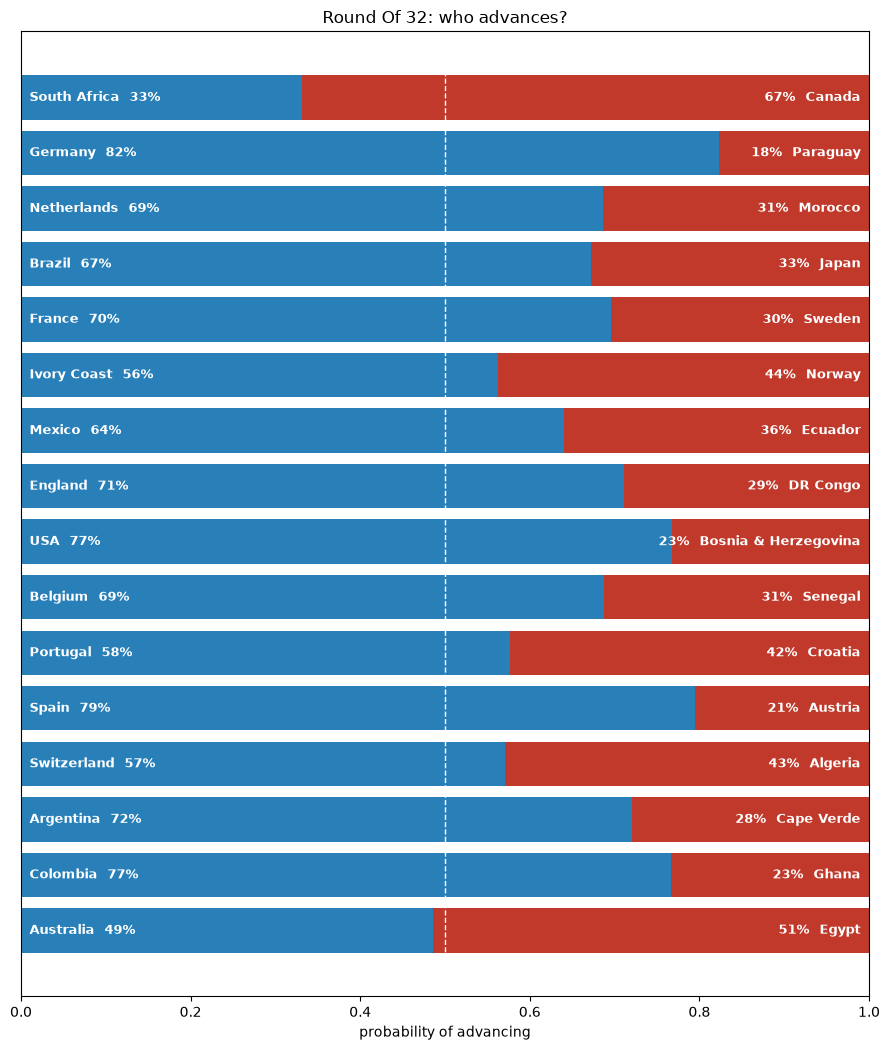

In [5]:
fig, ax = plt.subplots(figsize=(9, 0.6 * len(state.frontier) + 1))
for i, tie in enumerate(state.frontier):
    p1 = float(probs[tie.team1])
    ax.barh(i, p1, color=A_COLOR)
    ax.barh(i, 1 - p1, left=p1, color=B_COLOR)
    ax.text(0.01, i, f'{tie.team1}  {p1:.0%}', va='center', ha='left',
            color='white', fontsize=9, fontweight='bold')
    ax.text(0.99, i, f'{1 - p1:.0%}  {tie.team2}', va='center',
            ha='right', color='white', fontsize=9, fontweight='bold')
ax.axvline(0.5, color='white', lw=1, ls='--')
ax.set_yticks([]); ax.set_xlim(0, 1); ax.invert_yaxis()
ax.set_xlabel('probability of advancing')
ax.set_title(f'{label.title()}: who advances?')
plt.tight_layout(); plt.show()

## How far do they go?

Rolling the same conditioned simulation to the final gives each surviving team's title odds and full finish distribution.

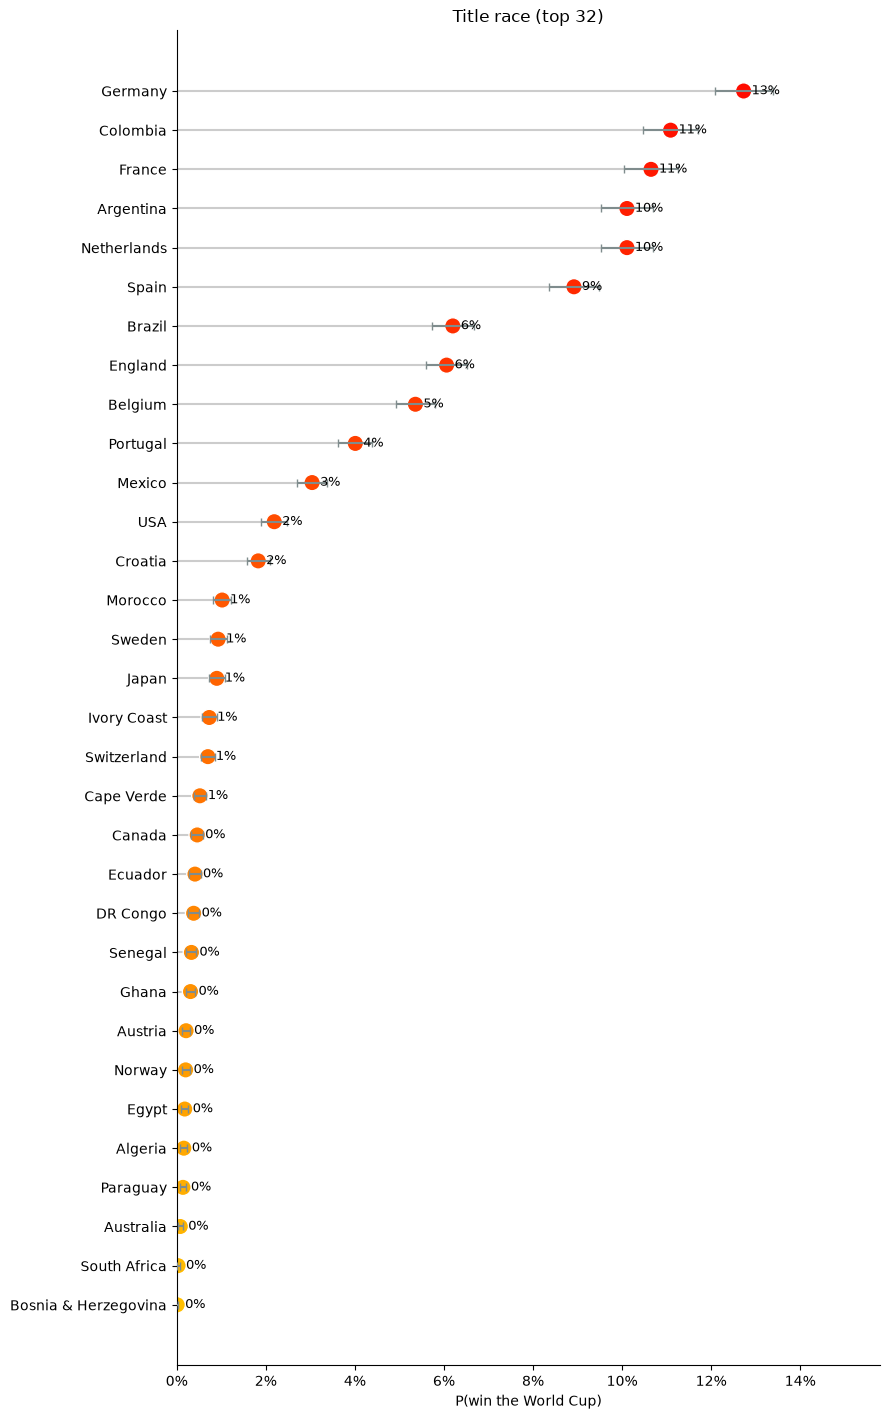

In [6]:
viz.plot_title_race(report, top_n=len(state.alive))
plt.tight_layout(); plt.show()

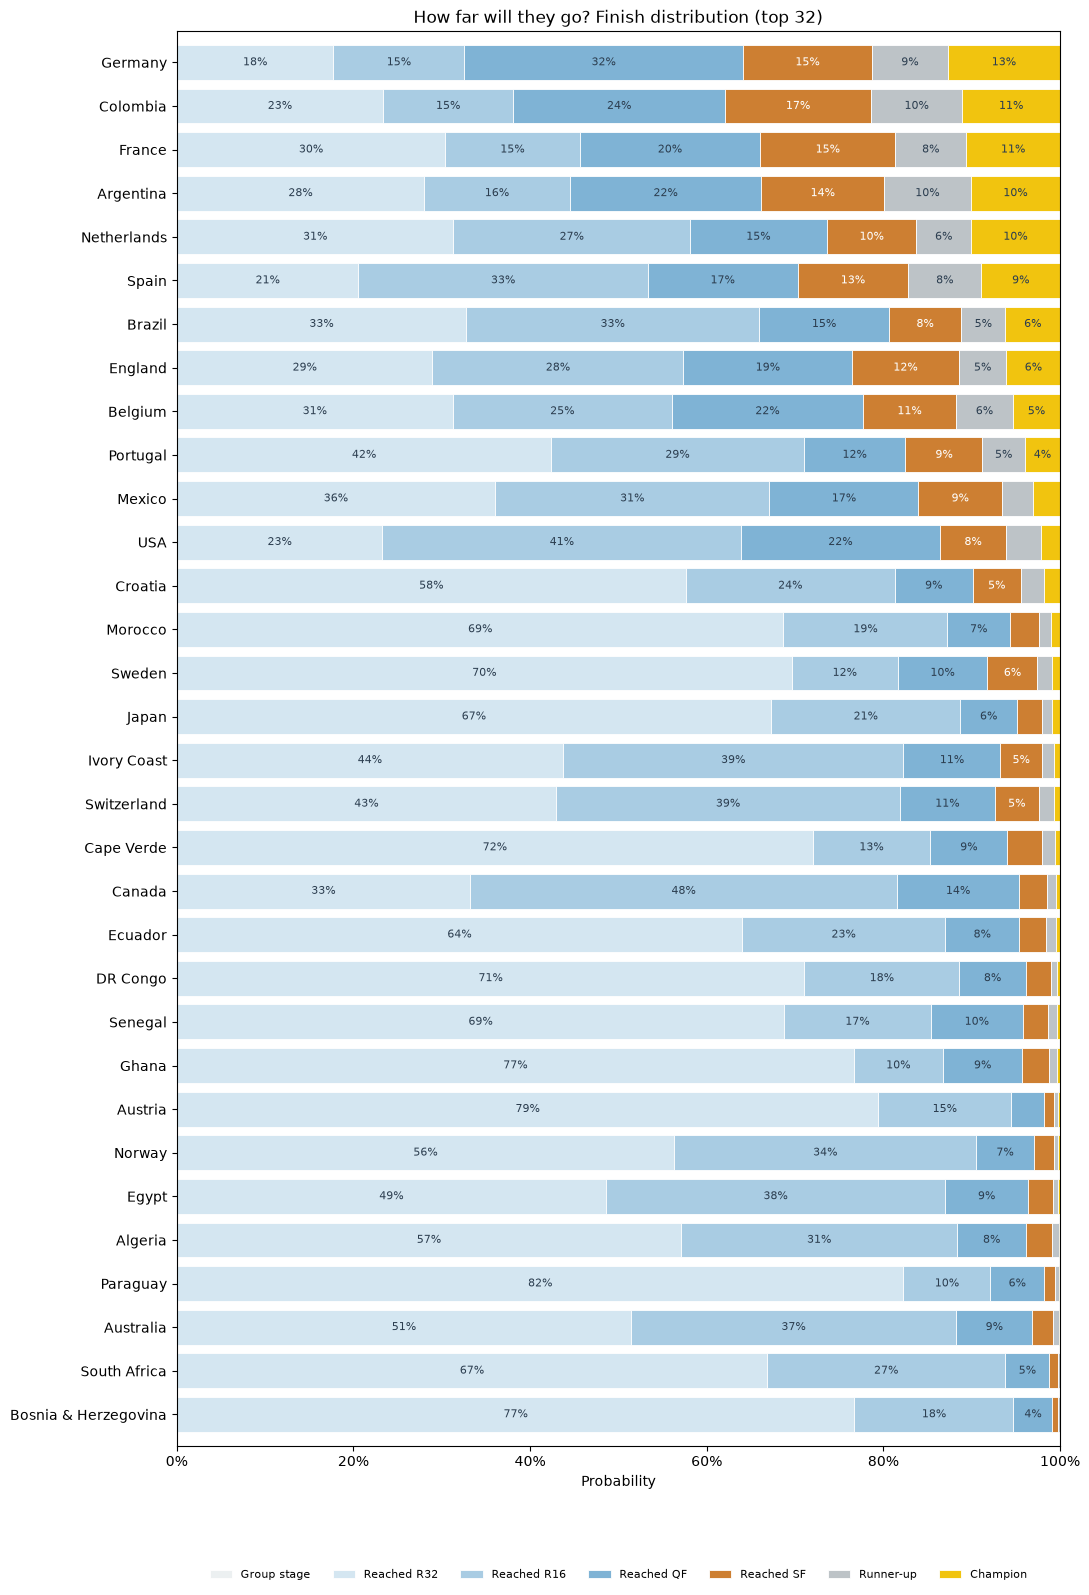

In [7]:
viz.plot_outcome_distribution(report, top_n=len(state.alive))
plt.tight_layout(); plt.show()

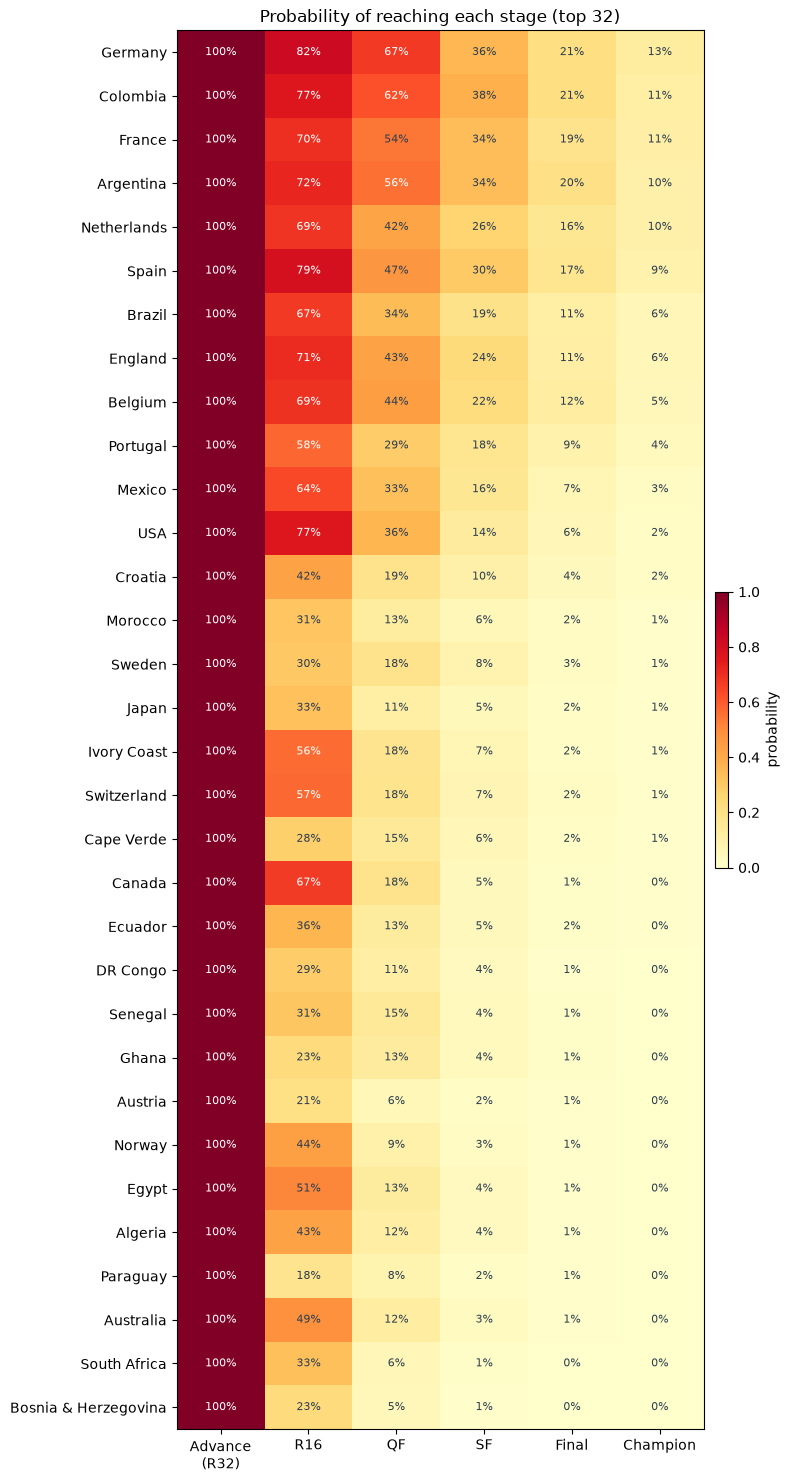

In [8]:
viz.plot_stage_heatmap(report, top_n=len(state.alive))
plt.tight_layout(); plt.show()

## Scorecard: predictions vs reality

Now that the round has been played, we grade every tie prediction.

In [9]:
actual = {frozenset((t.team1, t.team2)): t.winner
          for t in actual_knockout_ties(config).get(STAGE, ())}
recs, ps, ys = [], [], []
for tie in state.frontier:
    p1 = float(probs[tie.team1])
    w = actual.get(frozenset((tie.team1, tie.team2)))
    rec = {'match': f'{tie.team1} v {tie.team2}',
           'predicted': tie.team1 if p1 >= 0.5 else tie.team2,
           'confidence': round(max(p1, 1 - p1), 3),
           'actual': w or 'not played yet'}
    if w:
        y = 1.0 if w == tie.team1 else 0.0
        ps.append(p1); ys.append(y)
        rec['result'] = 'correct' if (p1 >= 0.5) == (y == 1.0) else 'upset'
    recs.append(rec)
scorecard = pd.DataFrame(recs)
if ps:
    ps, ys = np.array(ps), np.array(ys)
    pc = np.clip(ps, 1e-15, 1 - 1e-15)
    acc = np.mean((pc >= 0.5) == (ys == 1))
    brier = np.mean((ps - ys) ** 2)
    ll = -np.mean(ys * np.log(pc) + (1 - ys) * np.log(1 - pc))
    print(f'{len(ys)} ties scored | accuracy {acc:.0%} | '
          f'Brier {brier:.3f} | log-loss {ll:.3f}')
    print('(Lower Brier/log-loss is better; a 50/50 guess scores 0.250 / 0.693.)')
else:
    print(f'The {label} has not been played yet -- predictions only.')
scorecard

16 ties scored | accuracy 81% | Brier 0.182 | log-loss 0.557
(Lower Brier/log-loss is better; a 50/50 guess scores 0.250 / 0.693.)


,match,predicted,confidence,actual,result
0,South Africa v Canada,Canada,0.668,Canada,correct
1,Germany v Paraguay,Germany,0.823,Paraguay,upset
2,Netherlands v Morocco,Netherlands,0.687,Morocco,upset
3,Brazil v Japan,Brazil,0.672,Brazil,correct
4,France v Sweden,France,0.696,France,correct
5,Ivory Coast v Norway,Ivory Coast,0.563,Norway,upset
6,Mexico v Ecuador,Mexico,0.640,Mexico,correct
7,England v DR Congo,England,0.711,England,correct
8,USA v Bosnia & Herzegovina,USA,0.767,USA,correct
9,Belgium v Senegal,Belgium,0.688,Belgium,correct
